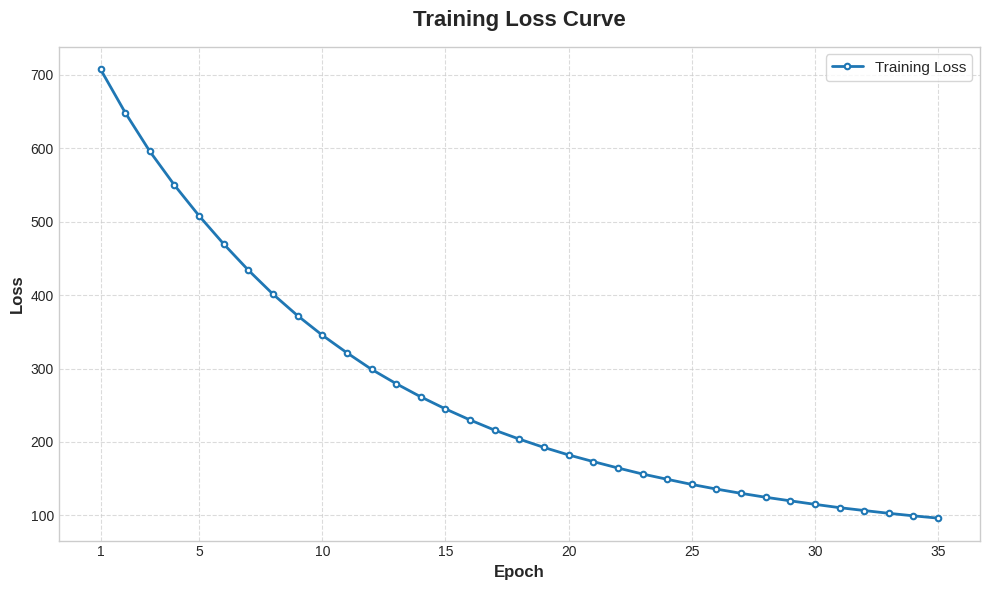

In [1]:
import matplotlib.pyplot as plt
import re

# 1. 제공해주신 원본 로그 데이터 (멀티라인 문자열)
raw_log = """
100%|██████████| 552/552 [01:57<00:00,  4.70it/s, Batch Loss=646.0135]
Epoch 1, Loss: 707.3286
100%|██████████| 552/552 [01:57<00:00,  4.72it/s, Batch Loss=593.2009]
Epoch 2, Loss: 648.3791
100%|██████████| 552/552 [01:57<00:00,  4.72it/s, Batch Loss=538.5913]
Epoch 3, Loss: 595.5992
100%|██████████| 552/552 [01:57<00:00,  4.72it/s, Batch Loss=549.4158]
Epoch 4, Loss: 549.5962
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=529.7224]
Epoch 5, Loss: 507.8467
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=433.5222]
Epoch 6, Loss: 469.4472
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=411.8180]
Epoch 7, Loss: 433.8573
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=354.1006]
Epoch 8, Loss: 401.1655
100%|██████████| 552/552 [01:57<00:00,  4.72it/s, Batch Loss=346.8177]
Epoch 9, Loss: 371.8795
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=294.0868]
Epoch 10, Loss: 345.3800
100%|██████████| 552/552 [01:56<00:00,  4.73it/s, Batch Loss=315.1357]
Epoch 11, Loss: 321.4150
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=278.4645]
Epoch 12, Loss: 298.8878
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=296.8436]
Epoch 13, Loss: 279.3460
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=242.4447]
Epoch 14, Loss: 261.4036
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=231.2561]
Epoch 15, Loss: 244.9930
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=247.6640]
Epoch 16, Loss: 229.9321
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=200.1956]
Epoch 17, Loss: 216.0493
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=210.5649]
Epoch 18, Loss: 203.8746
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=182.6401]
Epoch 19, Loss: 192.5359
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=152.5333]
Epoch 20, Loss: 182.3483
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=159.0689]
Epoch 21, Loss: 173.2819
100%|██████████| 552/552 [01:57<00:00,  4.72it/s, Batch Loss=165.4280]
Epoch 22, Loss: 164.5954
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=163.4939]
Epoch 23, Loss: 156.3752
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=159.4540]
Epoch 24, Loss: 149.1945
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=144.3854]
Epoch 25, Loss: 142.1728
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=124.0137]
Epoch 26, Loss: 135.8572
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=139.7455]
Epoch 27, Loss: 130.0714
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=122.8870]
Epoch 28, Loss: 124.7179
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=112.3714]
Epoch 29, Loss: 119.8762
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=112.6989]
Epoch 30, Loss: 115.0673
100%|██████████| 552/552 [01:57<00:00,  4.72it/s, Batch Loss=109.2945]
Epoch 31, Loss: 110.5764
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=104.6769]
Epoch 32, Loss: 106.6657
100%|██████████| 552/552 [01:56<00:00,  4.72it/s, Batch Loss=103.6893]
Epoch 33, Loss: 102.8787
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=98.0412] 
Epoch 34, Loss: 99.4272
100%|██████████| 552/552 [01:57<00:00,  4.71it/s, Batch Loss=94.1545] 
Epoch 35, Loss: 96.3018
"""

# 2. 데이터 파싱 (정규표현식 활용)
epochs = []
losses = []

# "Epoch 숫자, Loss: 숫자" 패턴 찾기
pattern = re.compile(r"Epoch (\d+), Loss: ([\d\.]+)")

for line in raw_log.strip().split('\n'):
    match = pattern.search(line)
    if match:
        epochs.append(int(match.group(1))) # Epoch 번호 저장
        losses.append(float(match.group(2))) # Loss 값 저장

# 3. 그래프 그리기 (Pythonic Style)
# 그래프 스타일 설정 (seaborn 스타일이 깔끔합니다)
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

# 데이터 플롯
ax.plot(epochs, losses, 
        linestyle='-',      # 실선
        linewidth=2,        # 선 굵기
        color='#1f77b4',    # 파란색 계열
        marker='o',         # 마커 추가
        markersize=4,       # 마커 크기
        markerfacecolor='white', # 마커 내부 색상
        markeredgewidth=1.5, # 마커 테두리 굵기
        label='Training Loss')

# 스타일링 (제목, 라벨 등)
ax.set_title('Training Loss Curve', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')

# X축 틱 설정 (1부터 35까지 5단위로 표시)
ax.set_xticks(range(0, max(epochs) + 1, 5))
if len(epochs) > 0:
    ax.set_xticks([1] + list(range(5, max(epochs) + 1, 5)))

# 그리드 및 레이아웃 최적화
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 범례 표시
ax.legend(frameon=True, fontsize=11)

# 그래프 표시
plt.show()